TASK 5: DATA VISUALISATION

5.1--> PLOT THE TOTAL TRANSACTION AND AMOUNT OVER TIME FOR A SELECTED STATE.

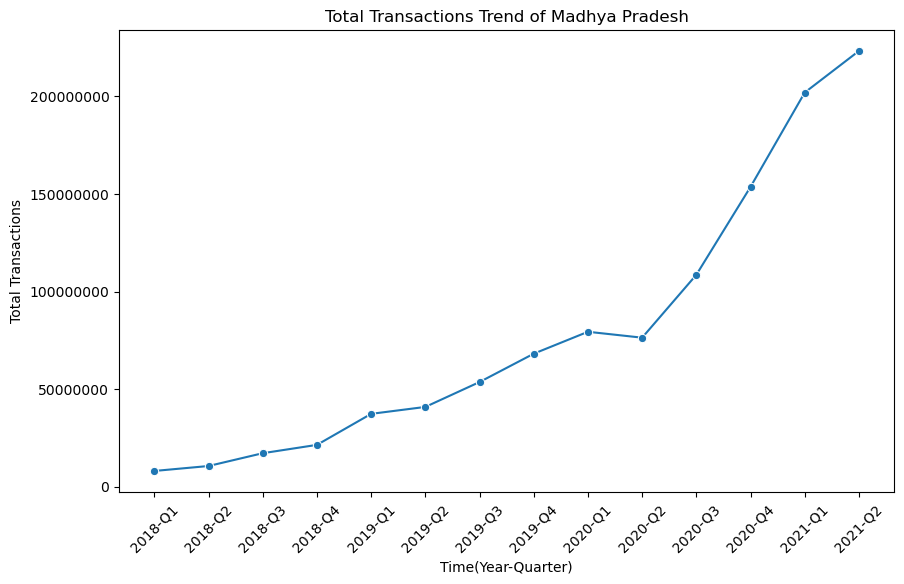

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
s_txnusers=pd.read_excel(r"C:\Users\sonali\Downloads\PhonePayData.xlsx",sheet_name='State_Txn and Users')
my_state='Madhya Pradesh'

# AGGREGATE 
res=s_txnusers.groupby(['State','Year','Quarter']).agg({
    'Transactions':'sum',
    'Amount (INR)':'sum'}).reset_index()

# MAKE A COLUMN FOR TIME (YEAR-QUARTER)
res=res[res['State']==my_state]
res=res.sort_values(['Year','Quarter'])
res['Time']=res['Year'].astype(str)+'-Q'+res['Quarter'].astype(str)

# PLOT TOTAL TRANSACTIONS OVER TIME
plt.figure(figsize=(10,6))
sns.lineplot(data=res,x='Time',y='Transactions',marker='o')
plt.title(f'Total Transactions Trend of {my_state}')
plt.xlabel('Time(Year-Quarter)')
plt.ylabel('Total Transactions')
plt.ticklabel_format(style='plain',axis='y')
plt.xticks(rotation=45)
plt.show()

INSIGHT--> THE TOTAL TRANSACTIONS HAS INCREASED OVER THE PERIOD OF TIME. THERE IS A SMALL DIP IN THE SECOND QUARTER Q2 OF 2020.
THIS MAY BE DUE TO THE LOCKDOWN AND COVID-19 AS THERE WAS COMPLETE LOCOKDOWN FOR THAT PERIOD.

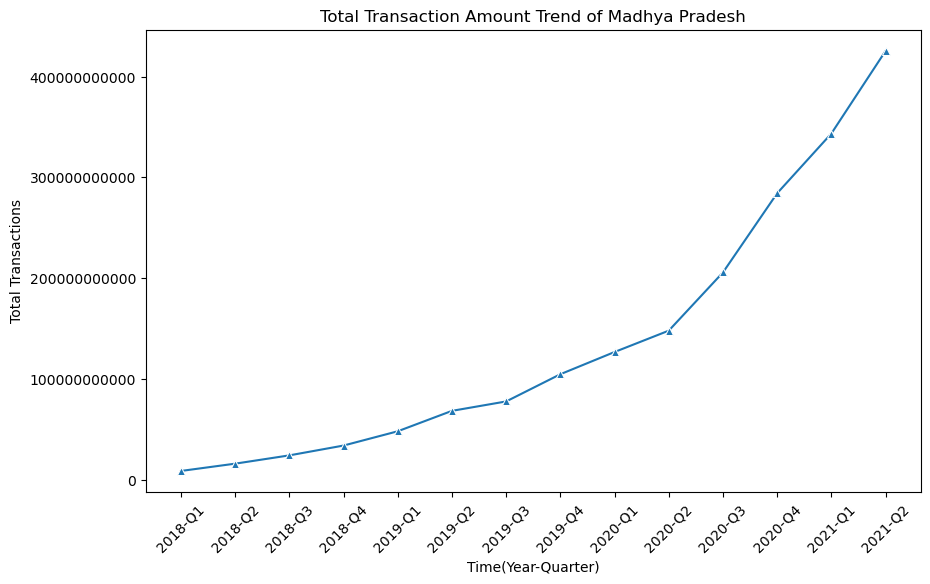

In [13]:
# PLOT TOTAL TRANSACTION AMOUNT OVER TIME
plt.figure(figsize=(10,6))
sns.lineplot(data=res,x='Time',y='Amount (INR)',marker='^')
plt.title(f'Total Transaction Amount Trend of {my_state}')
plt.xlabel('Time(Year-Quarter)')
plt.ylabel('Total Transactions')
plt.ticklabel_format(style='plain',axis='y')
plt.xticks(rotation=45)
plt.show()

INSIGHT--> THE TOTAL TRANSACTION AMOUNT HAS DRASTICALLY INCREASED OVER TIME. SHOWING GROWTH IN THE TOTAL AMOUNT SPEND OVER TIME.

5.2--> CREATE A PIE CHART SHOWING THE DISTRIBUTION OF TRANSACTION TYPES FOR A SPECIFIC QUARTER.

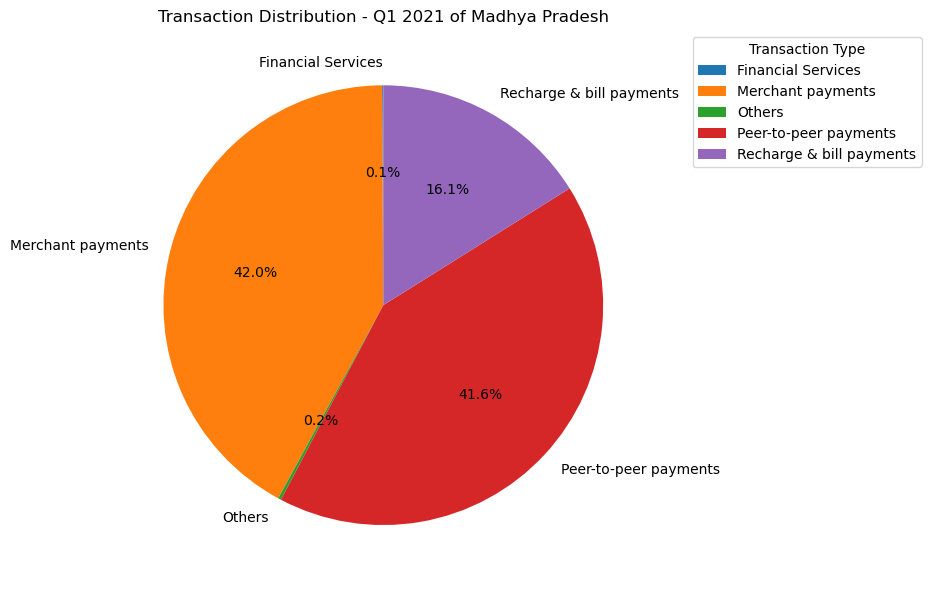

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
s_txnsplit=pd.read_excel(r"C:\Users\sonali\Downloads\PhonePayData.xlsx",sheet_name='State_TxnSplit')
year=2021
quarter=1
my_state='Madhya Pradesh'
filtered=s_txnsplit[(s_txnsplit['Year']==year) & (s_txnsplit['Quarter']==quarter) & (s_txnsplit['State']==my_state)]

# AGGREGATE DATA FOR MY STATE= MADHYA PRADESH
dist=(filtered.groupby('Transaction Type')['Transactions'].sum().reset_index())

# PLOTTING PIE CHART
plt.figure(figsize=(8,6))
plt.pie(dist['Transactions'],labels=dist['Transaction Type'],autopct="%1.1f%%",startangle=90)
plt.title(f'Transaction Distribution - Q{quarter} {year} of {my_state}')
plt.tight_layout()
plt.legend(title='Transaction Type', bbox_to_anchor=(1.05,1))
plt.show()

INSIGHT--> FOR Q1-2021 MADHYA PRADESH, MERCHANT PAYMENTS HAS HIGHEST TRANSACTIONS WITH 42% AND FINANCIAL SERVICES AS LOWEST.

5.3--> Visualize a population density of districts in a selected state. Create a bar plot.

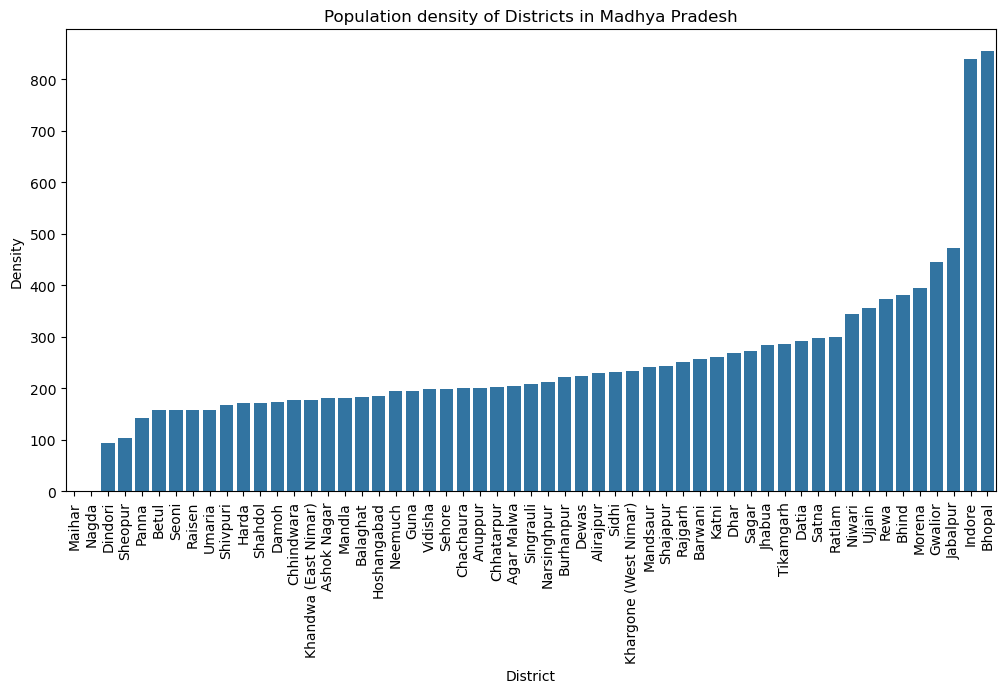

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
d_demo=pd.read_excel(r"C:\Users\sonali\Downloads\PhonePayData.xlsx",sheet_name='District Demographics')
my_state='Madhya Pradesh'
filter=d_demo[d_demo['State']==my_state]


# DISTRICT WISE DENSITY AGGREGATE
res=filter.groupby('District')['Density'].sum().reset_index()
res=res.sort_values(by='Density')

# PLOT A BAR CHART
plt.figure(figsize=(12,6))
sns.barplot(data=res,x='District',y='Density')
plt.title(f'Population density of Districts in {my_state}')
plt.xlabel('District')
plt.ylabel('Density')
plt.xticks(rotation=90)
plt.show()

INSIGHT--> In the state of MADHYA PRADESH,the district of INDORE has highest population density. While the state of MAIHAR has the lowest.